In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

coffee_full = pd.read_csv('coffee.csv')

In [3]:
coffee_red = coffee_full.sample(200)

In [4]:
coffee_full.head()

,user_id,age,drinks_coffee,height
0,4509,<21,False,64.538179
1,1864,>=21,True,65.824249
2,2060,<21,False,71.319854
3,7875,>=21,True,68.569404
4,6254,<21,True,64.020226


In [5]:
coffee_red["drinks_coffee"].mean()

np.float64(0.595)

In [6]:
coffee_red[coffee_red["drinks_coffee"] == True]["height"].mean()

np.float64(68.11962990858616)

In [9]:
sample = coffee_red.sample(200, replace=True)
sample[sample["drinks_coffee"] == True]["height"].mean()

np.float64(68.2153397472461)

In [11]:
samples_means = []

for i in range(10000):
    bootsample = coffee_red.sample(200, replace=True)
    samples_means.append(bootsample[bootsample["drinks_coffee"] == True]["height"].mean())

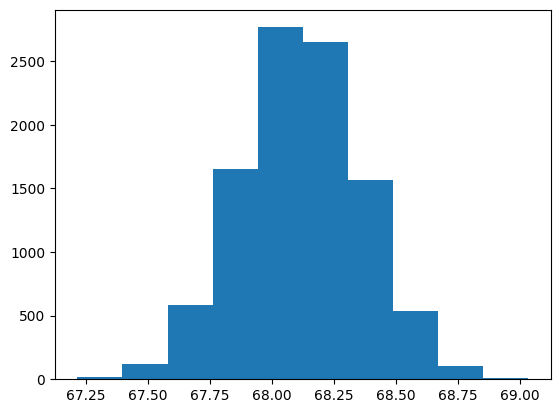

In [13]:
plt.hist(samples_means);

In [16]:
# creating confidence interval of 95% by taking 2.5 off the bottom and top 
np.percentile(samples_means,2.5), np.percentile(samples_means,97.5)

(np.float64(67.64081007098031), np.float64(68.58742413275891))

In [2]:
### Height Confidence Intervals 

import pandas as pd
import numpy as np

np.random.seed(42)

coffee_full = pd.read_csv('coffee.csv')
coffee_red = coffee_full.sample(200)

In [ ]:
# Proportion of people that drink coffee from sample
# coffee drinkers are stored in a boolean which convert to 0's/1's so can use mean
coffee_red.drinks_coffee.mean()

np.float64(0.595)

In [ ]:
# Proportion does not drink coffee
1 - coffee_red.drinks_coffee.mean()

np.float64(0.405)

In [ ]:
# avg height of coffee drinkers
coffee_red[coffee_red["drinks_coffee"]==True]["height"].mean()

np.float64(68.11962990858616)

In [15]:
coffee_red[coffee_red["drinks_coffee"]==False]["height"].mean()

np.float64(66.78492279927877)

In [28]:
coffee_new = coffee_red.sample(200,replace=True)

In [35]:
coffee_new.drinks_coffee.mean()

np.float64(0.585)

In [54]:
boot_sample = []

for i in range(10000):
    sample = coffee_red.sample(200,replace=True)
    boot_sample.append(sample[sample["drinks_coffee"]==False]["height"].mean())

In [55]:
import matplotlib.pyplot as plt

(array([   9.,   79.,  508., 1480., 2619., 2755., 1695.,  667.,  164.,
          24.]),
 array([65.25183529, 65.5499988 , 65.84816231, 66.14632582, 66.44448932,
        66.74265283, 67.04081634, 67.33897985, 67.63714336, 67.93530686,
        68.23347037]),
 <BarContainer object of 10 artists>)

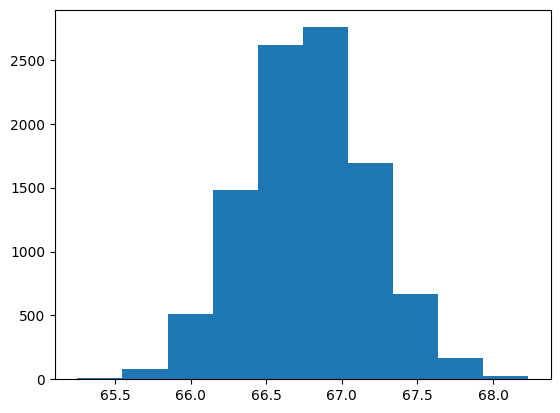

In [56]:
plt.hist(boot_sample)

In [57]:
np.percentile(boot_sample,2.5), np.percentile(boot_sample,97.5)

(np.float64(65.99245426275917), np.float64(67.58734663795654))

In [63]:
np.mean(boot_sample)

np.float64(66.77771989993948)

In [65]:
coffee_full[coffee_full["drinks_coffee"]==False]["height"].mean()

np.float64(66.443407762147)

### Difference in Means
- Similar to above, except using multiple values in the arrays
- drinks coffee / does not drink coffee in same variable

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

full_data = pd.read_csv('coffee.csv')
sample_data = full_data.sample(200)

In [71]:
diffs = []

for i in range(10000):
    bootsamp = sample_data.sample(200,replace=True)
    coffee = bootsamp[bootsamp["drinks_coffee"]==True]["height"].mean()
    no_coffee = bootsamp[bootsamp["drinks_coffee"]==False]["height"].mean()
    diffs.append(coffee - no_coffee)

In [72]:
np.percentile(diffs,2.5), np.percentile(diffs,97.5)

(np.float64(0.4042555972665078), np.float64(2.2278644443932865))